In [31]:
# import nessary libraries
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
#imagae preprocessing
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
# Import Keras layers, models, and optimizers from TensorFlow
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
# import nessary libraries
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import gradio as gr
import keras
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [14]:
Train_path = "/kaggle/input/chest-xray-covid19-pneumonia/Data/train"
Test_path  = "/kaggle/input/chest-xray-covid19-pneumonia/Data/test"
image_size = (128, 128)
batch_size = 4
num_classes = 3  

In [3]:
labels_dict = {
    "COVID19": 0,
    "NORMAL": 1s
    "PNEUMONIA": 2
}


In [5]:
def show_random_images_cv2(base_dir="dataset", num_images=12, image_size=(250, 128)):
    image_paths = []
    for brand in os.listdir(base_dir):
        brand_folder = os.path.join(base_dir, brand)
        if os.path.isdir(brand_folder):
            for img_file in os.listdir(brand_folder):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                    image_paths.append(os.path.join(brand_folder, img_file))

    selected = random.sample(image_paths, min(num_images, len(image_paths)))

    cols = 4
    rows = (len(selected) + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))

    for i, img_path in enumerate(selected):
        img = cv2.imread(img_path)
        if img is None:
            continue  # skip unreadable files
        img = cv2.resize(img, image_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert from BGR to RGB

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(os.path.dirname(img_path)))

    plt.tight_layout()
    plt.show()

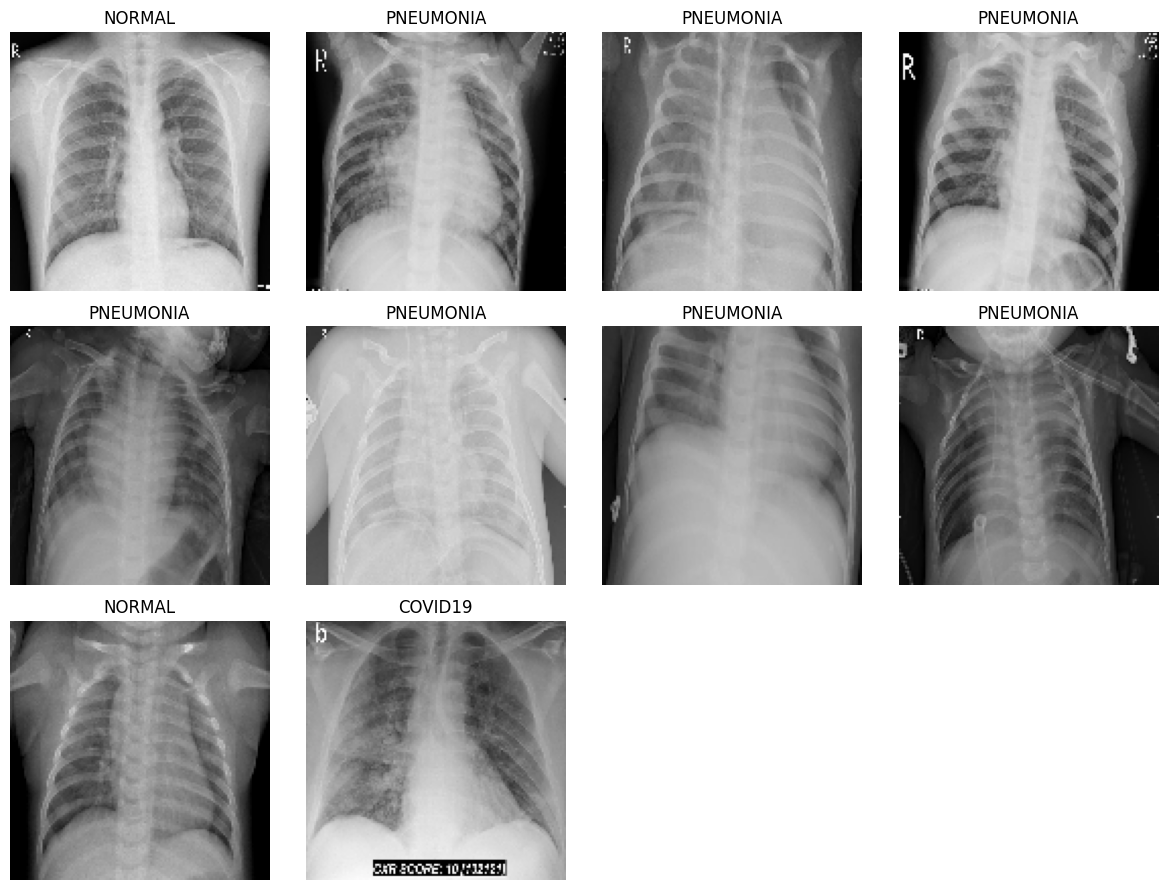

In [6]:
#use the function
show_random_images_cv2(base_dir=Train_path, num_images=10, image_size=image_size)

In [25]:
labels_dict = {
    "covid19": 0,
    "pneumonia": 1,
    "normal": 2
}


In [47]:
def load_data_binary(dataset_paths, labels_dict, image_size=(128,128), augment=False):
    X, y = [], []
    for dataset_path in dataset_paths:
        print("Looking in:", dataset_path)

        for folder in os.listdir(dataset_path):
            folder_lower = folder.lower()
            if folder_lower not in labels_dict:
                print("Skipping folder:", folder)
                continue

            label = labels_dict[folder_lower]
            folder_path = os.path.join(dataset_path, folder)
            print("Processing:", folder_path)

            for img_file in os.listdir(folder_path):
                if not img_file.lower().endswith((".png",".jpg",".jpeg")):
                    continue
                img_path = os.path.join(folder_path, img_file)
                img = cv2.imread(img_path)
                if img is None:
                    print("Could not read:", img_path)
                    continue

                img = cv2.resize(img, image_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img)
                y.append(label)

                if augment:
                    X.append(cv2.flip(img,1)); y.append(label)
                    for angle in [15, -15]:
                        M = cv2.getRotationMatrix2D((image_size[0]//2, image_size[1]//2), angle, 1)
                        X.append(cv2.warpAffine(img, M, image_size))
                        y.append(label)

    print(f"Loaded {len(X)} images")
    X = np.array(X, dtype="float32") / 255.0
    y = np.array(y, dtype="float32")
    
    return X, y


In [48]:
X_train, y_train = load_data_binary([Train_path], labels_dict, image_size)
X_test, y_test   = load_data_binary([Test_path], labels_dict, image_size)

Looking in: /kaggle/input/chest-xray-covid19-pneumonia/Data/train
Processing: /kaggle/input/chest-xray-covid19-pneumonia/Data/train/PNEUMONIA
Processing: /kaggle/input/chest-xray-covid19-pneumonia/Data/train/NORMAL
Processing: /kaggle/input/chest-xray-covid19-pneumonia/Data/train/COVID19
Loaded 5144 images
Looking in: /kaggle/input/chest-xray-covid19-pneumonia/Data/test
Processing: /kaggle/input/chest-xray-covid19-pneumonia/Data/test/PNEUMONIA
Processing: /kaggle/input/chest-xray-covid19-pneumonia/Data/test/NORMAL
Processing: /kaggle/input/chest-xray-covid19-pneumonia/Data/test/COVID19
Loaded 1288 images


In [49]:
print("Training data shape:", X_train.shape, y_train.shape)
print("Test data shape:", X_test.shape, y_test.shape)

Training data shape: (5144, 128, 128, 3) (5144,)
Test data shape: (1288, 128, 128, 3) (1288,)


In [50]:
from sklearn.preprocessing import OneHotEncoder

# Reshape to 2D
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

# Initialize encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit & transform
y_train = encoder.fit_transform(y_train)
y_test  = encoder.transform(y_test)

print("y_train one-hot shape:", y_train.shape)
print("y_test one-hot shape:", y_test.shape)


y_train one-hot shape: (5144, 3)
y_test one-hot shape: (1288, 3)


In [51]:
# ------------------------------
# 2. Load Pretrained Model
# ------------------------------
base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(128,128, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classifier



In [52]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
preds = Dense(3, activation="softmax")(x)   # 3 classes: COVID-19, Pneumonia, Normal

model = Model(inputs=base_model.input, outputs=preds)
model.summary()
# ------------------------------
# 3. Compile Model
# ------------------------------


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,040,579 (26.86 MB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [53]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]


In [54]:


history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 53s 174ms/step - accuracy: 0.4339 - loss: 1.8903 - val_accuracy: 0.6879 - val_loss: 0.6980 - learning_rate: 1.0000e-04
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6209 - loss: 1.0685 - val_accuracy: 0.7818 - val_loss: 0.4776 - learning_rate: 1.0000e-04
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6818 - loss: 0.8791 - val_accuracy: 0.8238 - val_loss: 0.4067 - learning_rate: 1.0000e-04
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7369 - loss: 0.6959 - val_accuracy: 0.8657 - val_loss: 0.3326 - learning_rate: 1.0000e-04
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7665 - loss: 0.5936 - val_accuracy: 0.8812 - val_loss: 0.2945 - learning_rate: 1.0000e-04
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8026 - loss: 0.5007 - val_accuracy: 0.8859 - val_loss: 0.2776 - learning_rate: 1.0000e-04
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - a

In [57]:

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9598 - loss: 0.1290
Test Accuracy: 0.9410, Test Loss: 0.1738


In [55]:
# حفظ الموديل بالكامل
model.save("covid-19.keras")
print("Modelsaved successfully!")

Modelsaved successfully!


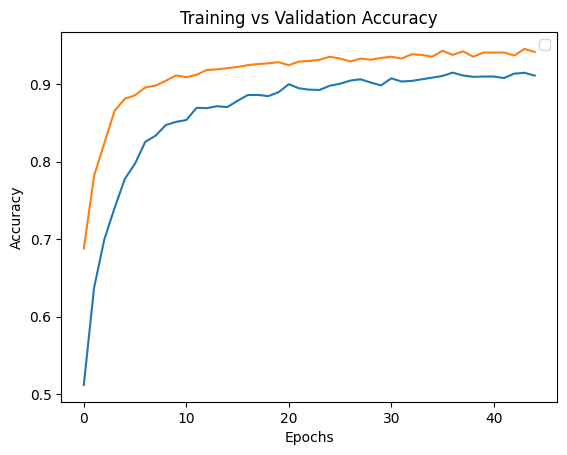

In [56]:
# --- Plot Accuracy ---
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'] )
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Classification Report:
              precision    recall  f1-score   support

    COVID-19       0.98      0.90      0.94       116
   Pneumonia       0.95      0.97      0.96       855
      Normal       0.90      0.89      0.89       317

    accuracy                           0.94      1288
   macro avg       0.94      0.92      0.93      1288
weighted avg       0.94      0.94      0.94      1288



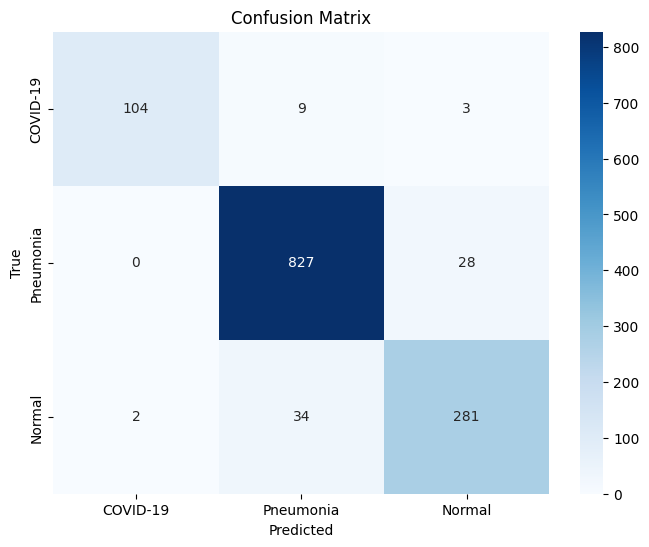

In [59]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# If y_test is one-hot encoded, convert to class indices
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test.astype(int)

# Predictions: get class indices from softmax probabilities
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names in order of labels
target_names = ["COVID-19", "Pneumonia", "Normal"]


# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [60]:
import gradio as gr
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# 1️⃣ Load your trained model

# 2️⃣ Class names in correct order
class_names = ["COVID-19", "Pneumonia", "Normal"]

# 3️⃣ Prediction function
def predict_xray(image):
    # Convert to numpy
    img = cv2.resize(np.array(image), (128, 128))   # resize same as training
    img = img / 255.0                               # normalize
    img = np.expand_dims(img, axis=0)               # add batch dimension

    # Prediction
    pred_probs = model.predict(img)[0]              # shape: (3,)

    # Return dictionary for Gradio
    return {name: float(prob) for name, prob in zip(class_names, pred_probs)}


In [61]:

# 4️⃣ Gradio Interface
interface = gr.Interface(
    fn=predict_xray,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="Chest X-ray Classifier",
    description="Upload a chest X-ray image and the model will classify it as COVID-19, Pneumonia, or Normal.",
    examples=None  # optional: you can add some sample X-rays here
)

interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://998f43f800c415ff4e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
